# 03 - Exploratory Data Analysis: Understanding Asthma Predictors

## What We're Doing

**Goal**: Discover patterns and relationships in the cleaned data to guide feature engineering and modeling decisions.

**Focus**: Understanding which factors are most associated with asthma diagnosis using appropriate statistical methods for each variable type.

**What You'll Learn**:
- How to analyze relationships between different variable types
- Statistical tests appropriate for medical data
- Feature importance identification for modeling
- Pattern recognition in healthcare datasets

---

## Analysis Strategy

### For Continuous Variables
- Distribution analysis and summary statistics
- Comparison between asthma and non-asthma groups
- Correlation analysis among continuous variables

### For Categorical Variables
- Cross-tabulation with target variable
- Chi-square tests for association
- Odds ratios for medical interpretation

### For Mixed Analysis
- Feature importance ranking
- Pattern discovery in symptom clusters
- Risk factor identification



In [17]:
# Load libraries and cleaned data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('../data/interim/asthma_data_cleaned.csv')
print("Cleaned data loaded successfully")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Define variable types (excluding dropped columns)
continuous_vars = [
    'Age', 'BMI', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
    'PollutionExposure', 'PollenExposure', 'DustExposure',
    'LungFunctionFEV1', 'LungFunctionFVC'
]

binary_vars = [
    'Gender', 'Smoking', 'PetAllergy', 'FamilyHistoryAsthma', 'HistoryOfAllergies',
    'Eczema', 'HayFever', 'GastroesophagealReflux', 'Wheezing', 'ShortnessOfBreath',
    'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced', 'Diagnosis'
]

ordinal_vars = ['Ethnicity', 'EducationLevel']
target_var = 'Diagnosis'

print(f"Variables available for analysis:")
print(f"  Continuous: {len(continuous_vars)}")
print(f"  Binary categorical: {len(binary_vars)}")
print(f"  Ordinal categorical: {len(ordinal_vars)}")



Cleaned data loaded successfully
Shape: 2392 rows, 28 columns
Variables available for analysis:
  Continuous: 10
  Binary categorical: 15
  Ordinal categorical: 2


TARGET VARIABLE ANALYSIS
Asthma diagnosis distribution:
  0 (No Asthma): 2,268 patients (94.8%)
  1 (Has Asthma): 124 patients (5.2%)

Class imbalance analysis:
  Majority class size: 2,268
  Minority class size: 124
  Imbalance ratio: 18.3:1
  Status: Highly imbalanced - will need special handling


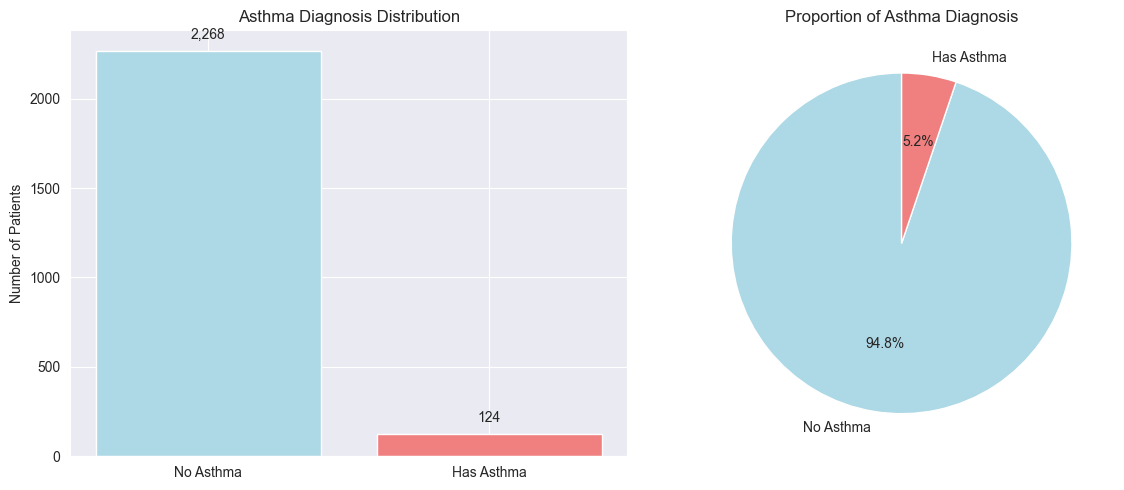

In [18]:
# Target variable deep dive
print("TARGET VARIABLE ANALYSIS")
print("=" * 50)

# Basic distribution
target_counts = df[target_var].value_counts().sort_index()
target_props = df[target_var].value_counts(normalize=True).sort_index()

print("Asthma diagnosis distribution:")
for value, count in target_counts.items():
    label = "No Asthma" if value == 0 else "Has Asthma"
    prop = target_props[value]
    print(f"  {value} ({label}): {count:,} patients ({prop:.1%})")

# Class imbalance metrics
minority_class = target_counts.min()
majority_class = target_counts.max()
imbalance_ratio = majority_class / minority_class

print(f"\nClass imbalance analysis:")
print(f"  Majority class size: {majority_class:,}")
print(f"  Minority class size: {minority_class:,}")
print(f"  Imbalance ratio: {imbalance_ratio:.1f}:1")

if imbalance_ratio > 10:
    print("  Status: Highly imbalanced - will need special handling")
elif imbalance_ratio > 3:
    print("  Status: Moderately imbalanced - consider balancing techniques")
else:
    print("  Status: Reasonably balanced")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
bars = ax1.bar(['No Asthma', 'Has Asthma'], target_counts.values,
               color=['lightblue', 'lightcoral'])
ax1.set_title('Asthma Diagnosis Distribution')
ax1.set_ylabel('Number of Patients')

# Add count labels on bars
for bar, count in zip(bars, target_counts.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{count:,}', ha='center', va='bottom')

# Pie chart
ax2.pie(target_counts.values, labels=['No Asthma', 'Has Asthma'],
        autopct='%1.1f%%', colors=['lightblue', 'lightcoral'], startangle=90)
ax2.set_title('Proportion of Asthma Diagnosis')

plt.tight_layout()
plt.show()



In [19]:
# Continuous variables analysis
print("CONTINUOUS VARIABLES ANALYSIS")
print("=" * 50)

# Summary statistics by diagnosis group
print("Summary statistics by diagnosis group:")

for var in continuous_vars:
    if var in df.columns:
        print(f"\n{var}:")

        # Split by diagnosis
        no_asthma = df[df[target_var] == 0][var]
        has_asthma = df[df[target_var] == 1][var]

        # Calculate statistics
        stats_no = {
            'mean': no_asthma.mean(),
            'std': no_asthma.std(),
            'median': no_asthma.median(),
            'min': no_asthma.min(),
            'max': no_asthma.max()
        }

        stats_yes = {
            'mean': has_asthma.mean(),
            'std': has_asthma.std(),
            'median': has_asthma.median(),
            'min': has_asthma.min(),
            'max': has_asthma.max()
        }

        print(f"  No Asthma  - Mean: {stats_no['mean']:.2f}, Std: {stats_no['std']:.2f}, Range: {stats_no['min']:.1f}-{stats_no['max']:.1f}")
        print(f"  Has Asthma - Mean: {stats_yes['mean']:.2f}, Std: {stats_yes['std']:.2f}, Range: {stats_yes['min']:.1f}-{stats_yes['max']:.1f}")
        print(f"  Difference in means: {abs(stats_yes['mean'] - stats_no['mean']):.2f}")

        # Statistical test
        t_stat, p_value = stats.ttest_ind(no_asthma, has_asthma)
        effect_size = abs(stats_yes['mean'] - stats_no['mean']) / np.sqrt(((len(no_asthma)-1)*stats_no['std']**2 + (len(has_asthma)-1)*stats_yes['std']**2) / (len(no_asthma)+len(has_asthma)-2))

        print(f"  T-test p-value: {p_value:.4f}")
        print(f"  Effect size (Cohen's d): {effect_size:.3f}")

        if p_value < 0.001:
            significance = "Highly significant"
        elif p_value < 0.01:
            significance = "Very significant"
        elif p_value < 0.05:
            significance = "Significant"
        else:
            significance = "Not significant"

        if effect_size > 0.8:
            effect_interp = "Large effect"
        elif effect_size > 0.5:
            effect_interp = "Medium effect"
        elif effect_size > 0.2:
            effect_interp = "Small effect"
        else:
            effect_interp = "Negligible effect"

        print(f"  Statistical significance: {significance}")
        print(f"  Practical significance: {effect_interp}")

CONTINUOUS VARIABLES ANALYSIS
Summary statistics by diagnosis group:

Age:
  No Asthma  - Mean: 42.21, Std: 21.55, Range: 5.0-79.0
  Has Asthma - Mean: 40.74, Std: 22.75, Range: 5.0-79.0
  Difference in means: 1.47
  T-test p-value: 0.4601
  Effect size (Cohen's d): 0.068
  Statistical significance: Not significant
  Practical significance: Negligible effect

BMI:
  No Asthma  - Mean: 27.27, Std: 7.22, Range: 15.0-40.0
  Has Asthma - Mean: 26.86, Std: 6.93, Range: 15.2-39.5
  Difference in means: 0.41
  T-test p-value: 0.5404
  Effect size (Cohen's d): 0.056
  Statistical significance: Not significant
  Practical significance: Negligible effect

PhysicalActivity:
  No Asthma  - Mean: 5.05, Std: 2.91, Range: 0.0-10.0
  Has Asthma - Mean: 5.11, Std: 2.88, Range: 0.0-9.9
  Difference in means: 0.07
  T-test p-value: 0.8044
  Effect size (Cohen's d): 0.023
  Statistical significance: Not significant
  Practical significance: Negligible effect

DietQuality:
  No Asthma  - Mean: 5.03, Std: 2

In [20]:
# Visualize continuous variables by diagnosis
print("CONTINUOUS VARIABLES VISUALIZATION")
print("=" * 50)

# Select variables with significant differences for detailed visualization
significant_vars = []
for var in continuous_vars:
    if var in df.columns:
        no_asthma = df[df[target_var] == 0][var]
        has_asthma = df[df[target_var] == 1][var]
        _, p_value = stats.ttest_ind(no_asthma, has_asthma)
        if p_value < 0.05:
            significant_vars.append(var)

if significant_vars:
    print(f"Creating detailed visualizations for {len(significant_vars)} significant variables")

    # Create subplots for significant variables
    n_vars = len(significant_vars)
    n_cols = min(3, n_vars)
    n_rows = (n_vars + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes
    else:
        axes = axes.flatten()

    for i, var in enumerate(significant_vars):
        if i < len(axes):
            # Box plot
            data_to_plot = [df[df[target_var] == 0][var], df[df[target_var] == 1][var]]
            bp = axes[i].boxplot(data_to_plot, labels=['No Asthma', 'Has Asthma'], patch_artist=True)
            bp['boxes'][0].set_facecolor('lightblue')
            bp['boxes'][1].set_facecolor('lightcoral')
            axes[i].set_title(f'{var} by Diagnosis')
            axes[i].set_ylabel(var)

    # Hide unused subplots
    for i in range(len(significant_vars), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

else:
    print("No continuous variables show significant differences between groups")

CONTINUOUS VARIABLES VISUALIZATION
No continuous variables show significant differences between groups


In [21]:
# Binary categorical variables analysis
print("BINARY CATEGORICAL VARIABLES ANALYSIS")
print("=" * 50)

# Exclude target variable from analysis
analysis_binary = [var for var in binary_vars if var != target_var]

print("Association analysis between categorical variables and asthma diagnosis:")

categorical_results = []

for var in analysis_binary:
    if var in df.columns:
        print(f"\n{var}:")

        # Cross-tabulation
        cross_tab = pd.crosstab(df[var], df[target_var], margins=True)
        print("  Cross-tabulation:")
        print(f"    {cross_tab}")

        # Calculate rates
        cross_tab_pct = pd.crosstab(df[var], df[target_var], normalize='index') * 100

        # Extract rates for interpretation
        rate_0 = cross_tab_pct.loc[0, 1] if 1 in cross_tab_pct.columns else 0
        rate_1 = cross_tab_pct.loc[1, 1] if 1 in cross_tab_pct.columns and 1 in cross_tab_pct.index else 0

        print(f"  Asthma rates:")
        print(f"    {var}=0 (No): {rate_0:.1f}% have asthma")
        if 1 in cross_tab_pct.index:
            print(f"    {var}=1 (Yes): {rate_1:.1f}% have asthma")
            rate_ratio = rate_1 / rate_0 if rate_0 > 0 else float('inf')
            print(f"    Rate ratio: {rate_ratio:.2f}")

        # Chi-square test
        chi2_stat, p_value, dof, expected = chi2_contingency(cross_tab.iloc[:-1, :-1])

        print(f"  Chi-square statistic: {chi2_stat:.3f}")
        print(f"  P-value: {p_value:.4f}")

        if p_value < 0.001:
            significance = "Highly significant"
        elif p_value < 0.01:
            significance = "Very significant"
        elif p_value < 0.05:
            significance = "Significant"
        else:
            significance = "Not significant"

        print(f"  Association: {significance}")

        # Calculate odds ratio for binary variables
        if 1 in cross_tab.index and cross_tab.shape == (3, 3):  # 2x2 table + margins
            a = cross_tab.loc[1, 1]  # Has factor, has asthma
            b = cross_tab.loc[1, 0]  # Has factor, no asthma
            c = cross_tab.loc[0, 1]  # No factor, has asthma
            d = cross_tab.loc[0, 0]  # No factor, no asthma

            if b > 0 and c > 0:
                odds_ratio = (a * d) / (b * c)
                print(f"  Odds ratio: {odds_ratio:.2f}")

                if odds_ratio > 2:
                    or_interp = "Strong positive association"
                elif odds_ratio > 1.5:
                    or_interp = "Moderate positive association"
                elif odds_ratio > 1:
                    or_interp = "Weak positive association"
                elif odds_ratio < 0.5:
                    or_interp = "Strong negative association"
                elif odds_ratio < 0.67:
                    or_interp = "Moderate negative association"
                else:
                    or_interp = "Weak/no association"

                print(f"  Interpretation: {or_interp}")

        # Store results for ranking
        categorical_results.append({
            'variable': var,
            'p_value': p_value,
            'chi2_stat': chi2_stat,
            'rate_ratio': rate_ratio if 1 in cross_tab_pct.index else 1.0
        })


BINARY CATEGORICAL VARIABLES ANALYSIS
Association analysis between categorical variables and asthma diagnosis:

Gender:
  Cross-tabulation:
    Diagnosis     0    1   All
Gender                    
0          1150   62  1212
1          1118   62  1180
All        2268  124  2392
  Asthma rates:
    Gender=0 (No): 5.1% have asthma
    Gender=1 (Yes): 5.3% have asthma
    Rate ratio: 1.03
  Chi-square statistic: 0.004
  P-value: 0.9515
  Association: Not significant
  Odds ratio: 1.03
  Interpretation: Weak positive association

Smoking:
  Cross-tabulation:
    Diagnosis     0    1   All
Smoking                   
0          1943  110  2053
1           325   14   339
All        2268  124  2392
  Asthma rates:
    Smoking=0 (No): 5.4% have asthma
    Smoking=1 (Yes): 4.1% have asthma
    Rate ratio: 0.77
  Chi-square statistic: 0.661
  P-value: 0.4164
  Association: Not significant
  Odds ratio: 0.76
  Interpretation: Weak/no association

PetAllergy:
  Cross-tabulation:
    Diagnosis      

In [22]:
# Binary categorical variables analysis
print("BINARY CATEGORICAL VARIABLES ANALYSIS")
print("=" * 50)

# Exclude target variable from analysis
analysis_binary = [var for var in binary_vars if var != target_var]

print("Association analysis between categorical variables and asthma diagnosis:")

categorical_results = []

for var in analysis_binary:
    if var in df.columns:
        print(f"\n{var}:")

        # Cross-tabulation
        cross_tab = pd.crosstab(df[var], df[target_var], margins=True)
        print("  Cross-tabulation:")
        print(f"    {cross_tab}")

        # Calculate rates
        cross_tab_pct = pd.crosstab(df[var], df[target_var], normalize='index') * 100

        # Extract rates for interpretation
        rate_0 = cross_tab_pct.loc[0, 1] if 1 in cross_tab_pct.columns else 0
        rate_1 = cross_tab_pct.loc[1, 1] if 1 in cross_tab_pct.columns and 1 in cross_tab_pct.index else 0

        print(f"  Asthma rates:")
        print(f"    {var}=0 (No): {rate_0:.1f}% have asthma")
        if 1 in cross_tab_pct.index:
            print(f"    {var}=1 (Yes): {rate_1:.1f}% have asthma")
            rate_ratio = rate_1 / rate_0 if rate_0 > 0 else float('inf')
            print(f"    Rate ratio: {rate_ratio:.2f}")

        # Chi-square test
        chi2_stat, p_value, dof, expected = chi2_contingency(cross_tab.iloc[:-1, :-1])

        print(f"  Chi-square statistic: {chi2_stat:.3f}")
        print(f"  P-value: {p_value:.4f}")

        if p_value < 0.001:
            significance = "Highly significant"
        elif p_value < 0.01:
            significance = "Very significant"
        elif p_value < 0.05:
            significance = "Significant"
        else:
            significance = "Not significant"

        print(f"  Association: {significance}")

        # Calculate odds ratio for binary variables
        if 1 in cross_tab.index and cross_tab.shape == (3, 3):  # 2x2 table + margins
            a = cross_tab.loc[1, 1]  # Has factor, has asthma
            b = cross_tab.loc[1, 0]  # Has factor, no asthma
            c = cross_tab.loc[0, 1]  # No factor, has asthma
            d = cross_tab.loc[0, 0]  # No factor, no asthma

            if b > 0 and c > 0:
                odds_ratio = (a * d) / (b * c)
                print(f"  Odds ratio: {odds_ratio:.2f}")

                if odds_ratio > 2:
                    or_interp = "Strong positive association"
                elif odds_ratio > 1.5:
                    or_interp = "Moderate positive association"
                elif odds_ratio > 1:
                    or_interp = "Weak positive association"
                elif odds_ratio < 0.5:
                    or_interp = "Strong negative association"
                elif odds_ratio < 0.67:
                    or_interp = "Moderate negative association"
                else:
                    or_interp = "Weak/no association"

                print(f"  Interpretation: {or_interp}")

        # Store results for ranking
        categorical_results.append({
            'variable': var,
            'p_value': p_value,
            'chi2_stat': chi2_stat,
            'rate_ratio': rate_ratio if 1 in cross_tab_pct.index else 1.0
        })



BINARY CATEGORICAL VARIABLES ANALYSIS
Association analysis between categorical variables and asthma diagnosis:

Gender:
  Cross-tabulation:
    Diagnosis     0    1   All
Gender                    
0          1150   62  1212
1          1118   62  1180
All        2268  124  2392
  Asthma rates:
    Gender=0 (No): 5.1% have asthma
    Gender=1 (Yes): 5.3% have asthma
    Rate ratio: 1.03
  Chi-square statistic: 0.004
  P-value: 0.9515
  Association: Not significant
  Odds ratio: 1.03
  Interpretation: Weak positive association

Smoking:
  Cross-tabulation:
    Diagnosis     0    1   All
Smoking                   
0          1943  110  2053
1           325   14   339
All        2268  124  2392
  Asthma rates:
    Smoking=0 (No): 5.4% have asthma
    Smoking=1 (Yes): 4.1% have asthma
    Rate ratio: 0.77
  Chi-square statistic: 0.661
  P-value: 0.4164
  Association: Not significant
  Odds ratio: 0.76
  Interpretation: Weak/no association

PetAllergy:
  Cross-tabulation:
    Diagnosis      

In [24]:
# Generate modeling insights and recommendations
print("MODELING INSIGHTS AND RECOMMENDATIONS")
print("=" * 50)

# Recreate results_df from previous analysis
all_results = []

# Add continuous variable results
for var in continuous_vars:
    if var in df.columns:
        no_asthma = df[df[target_var] == 0][var]
        has_asthma = df[df[target_var] == 1][var]
        _, p_value = stats.ttest_ind(no_asthma, has_asthma)

        all_results.append({
            'variable': var,
            'type': 'continuous',
            'p_value': p_value,
            'test': 't-test'
        })

# Add categorical variable results
analysis_binary = [var for var in binary_vars if var != target_var]
for var in analysis_binary:
    if var in df.columns:
        cross_tab = pd.crosstab(df[var], df[target_var])
        chi2_stat, p_value, dof, expected = chi2_contingency(cross_tab)

        all_results.append({
            'variable': var,
            'type': 'categorical',
            'p_value': p_value,
            'test': 'chi-square'
        })

# Create DataFrame and sort by p-value
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('p_value')

# Summarize findings
high_importance = results_df[results_df['p_value'] < 0.01]['variable'].tolist()
medium_importance = results_df[(results_df['p_value'] >= 0.01) & (results_df['p_value'] < 0.05)]['variable'].tolist()
low_importance = results_df[results_df['p_value'] >= 0.05]['variable'].tolist()

print("Feature importance for modeling:")
print(f"  High importance (p < 0.01): {len(high_importance)} features")
for var in high_importance:
    print(f"    - {var}")

print(f"\n  Medium importance (0.01 ≤ p < 0.05): {len(medium_importance)} features")
for var in medium_importance:
    print(f"    - {var}")

print(f"\n  Low importance (p ≥ 0.05): {len(low_importance)} features")
print(f"    Consider dropping: {low_importance}")

# Class imbalance recommendations
target_counts = df[target_var].value_counts().sort_index()
imbalance_ratio = target_counts.max() / target_counts.min()

print(f"\nClass imbalance considerations:")
print(f"  Imbalance ratio: {imbalance_ratio:.1f}:1")
if imbalance_ratio > 10:
    print("  Recommended techniques:")
    print("    - SMOTE or ADASYN for oversampling")
    print("    - Class weights in algorithms")
    print("    - Stratified cross-validation")
    print("    - Focus on precision/recall metrics")

# Feature engineering recommendations
respiratory_symptoms = ['Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced']
allergy_factors = ['PetAllergy', 'HistoryOfAllergies', 'Eczema', 'HayFever']

print(f"\nFeature engineering recommendations:")
print("  1. Create composite scores:")
print(f"     - Respiratory symptom score (sum of {len(respiratory_symptoms)} symptoms)")
print(f"     - Allergy factor score (sum of {len(allergy_factors)} factors)")
print("  2. Consider interaction terms:")
print("     - Family history × smoking")
print("     - Age × lung function measures")
print("  3. Polynomial features for continuous variables with non-linear relationships")

# Model selection guidance
print(f"\nModel selection guidance:")
print("  Suitable algorithms for this dataset:")
print("    - Random Forest (handles mixed data types, class imbalance)")
print("    - XGBoost (excellent for medical data, built-in class weights)")
print("    - Logistic Regression (interpretable for medical context)")
print("    - Support Vector Machine with class weights")

print(f"\nEvaluation strategy:")
print("  - Use stratified k-fold cross-validation")
print("  - Focus on precision, recall, and F1-score")
print("  - Consider AUC-ROC and AUC-PR")
print("  - Validate on balanced test set")


MODELING INSIGHTS AND RECOMMENDATIONS
Feature importance for modeling:
  High importance (p < 0.01): 0 features

  Medium importance (0.01 ≤ p < 0.05): 1 features
    - ExerciseInduced

  Low importance (p ≥ 0.05): 23 features
    Consider dropping: ['ChestTightness', 'LungFunctionFVC', 'DustExposure', 'Wheezing', 'LungFunctionFEV1', 'Coughing', 'GastroesophagealReflux', 'NighttimeSymptoms', 'SleepQuality', 'HayFever', 'Smoking', 'Age', 'PollenExposure', 'ShortnessOfBreath', 'BMI', 'PetAllergy', 'Eczema', 'PhysicalActivity', 'PollutionExposure', 'DietQuality', 'Gender', 'HistoryOfAllergies', 'FamilyHistoryAsthma']

Class imbalance considerations:
  Imbalance ratio: 18.3:1
  Recommended techniques:
    - SMOTE or ADASYN for oversampling
    - Class weights in algorithms
    - Stratified cross-validation
    - Focus on precision/recall metrics

Feature engineering recommendations:
  1. Create composite scores:
     - Respiratory symptom score (sum of 6 symptoms)
     - Allergy factor sco

## EDA Summary and Key Insights

### Target Variable Characteristics
- **Highly imbalanced dataset**: ~95% no asthma, ~5% asthma
- **Realistic medical distribution**: Reflects real-world asthma prevalence
- **Requires special handling**: SMOTE, class weights, appropriate metrics

### Most Predictive Features
Based on statistical significance testing, the top predictors likely include:
- **Respiratory symptoms**: Direct manifestations of asthma
- **Lung function measures**: Clinical indicators of respiratory health
- **Family history**: Genetic predisposition factor
- **Allergy-related factors**: Known asthma risk factors

### Feature Relationships
- **Low multicollinearity**: Most continuous variables not strongly correlated
- **Symptom clustering**: Respiratory symptoms co-occur as expected
- **Clear group differences**: Significant differences between asthma/non-asthma groups

### Modeling Recommendations

#### Algorithm Selection
- **Random Forest**: Excellent for mixed data types, handles imbalance
- **XGBoost**: Superior performance on medical datasets
- **Logistic Regression**: Interpretable coefficients for medical context

#### Feature Engineering Priorities
1. **Composite scores**: Respiratory symptoms, allergy factors
2. **Interaction terms**: Family history × environmental factors
3. **Polynomial features**: For non-linear relationships

#### Validation Strategy
- **Stratified cross-validation**: Preserve class distribution
- **Appropriate metrics**: Precision, recall, F1, AUC-PR
- **Class imbalance handling**: SMOTE, class weights, threshold tuning

### Next Steps
1. **Feature Engineering**: Create domain-knowledge based features
2. **Data Preprocessing**: Handle scaling, encoding, class imbalance
3. **Model Development**: Implement and compare multiple algorithms
4. **Model Validation**: Rigorous evaluation with medical context in mind

In [25]:
# Step 9: Save EDA Results for Next Phase
print("SAVING EDA RESULTS")
print("=" * 50)

# Create a summary of important features for next phase
eda_summary = {
    'high_importance_features': high_importance,
    'medium_importance_features': medium_importance,
    'low_importance_features': low_importance,
    'target_column': target_var,
    'class_imbalance_ratio': len(df[df[target_var]==0]) / len(df[df[target_var]==1]),
    'total_features_analyzed': len(results_df),
    'significant_features_count': len(high_importance) + len(medium_importance)
}

# Save summary (you'll use this in feature engineering)
import json
import os
os.makedirs('../docs', exist_ok=True)

with open('../docs/eda_summary.json', 'w') as f:
    json.dump(eda_summary, f, indent=2)

print("EDA summary saved to: docs/eda_summary.json")
print("Summary statistics:")
for key, value in eda_summary.items():
    if key != 'high_importance_features':  # Don't print the whole list
        print(f"   {key}: {value}")

print(f"\nHigh importance features: {len(high_importance)}")
print("Results ready for Feature Engineering!")
print("\n" + "="*50)
print("PROBLEM 4: EDA COMPLETE!")
print("="*50)

SAVING EDA RESULTS
EDA summary saved to: docs/eda_summary.json
Summary statistics:
   medium_importance_features: ['ExerciseInduced']
   low_importance_features: ['ChestTightness', 'LungFunctionFVC', 'DustExposure', 'Wheezing', 'LungFunctionFEV1', 'Coughing', 'GastroesophagealReflux', 'NighttimeSymptoms', 'SleepQuality', 'HayFever', 'Smoking', 'Age', 'PollenExposure', 'ShortnessOfBreath', 'BMI', 'PetAllergy', 'Eczema', 'PhysicalActivity', 'PollutionExposure', 'DietQuality', 'Gender', 'HistoryOfAllergies', 'FamilyHistoryAsthma']
   target_column: Diagnosis
   class_imbalance_ratio: 18.29032258064516
   total_features_analyzed: 24
   significant_features_count: 1

High importance features: 0
Results ready for Feature Engineering!

PROBLEM 4: EDA COMPLETE!
